# Trabajo Práctico Final — Predicción de accidentes cerebrovasculares

## Propuesta de investigación

Según la OMS, el **accidente cerebrovascular (ACV)** es la segunda causa de muerte a nivel mundial. En un contexto clínico, detectar tempranamente a pacientes con mayor riesgo permite priorizar estudios, seguimiento y prevención secundaria.

**Pregunta de investigación:** ¿Es posible predecir si un paciente sufrirá un ACV a partir de variables demográficas, clínicas y de estilo de vida?

**Objetivo:** construir un clasificador binario que estime la probabilidad de ACV (`stroke = 1`) y evaluar su desempeño con métricas adecuadas para clases desbalanceadas.

**Fuente de datos:** [Stroke Prediction Dataset](https://www.kaggle.com/datasets/fedesoriano/stroke-prediction-dataset) — Fedesoriano, Kaggle (2021). Cada fila representa un paciente con atributos como edad, hipertensión, enfermedad cardíaca, glucosa, IMC y hábito tabáquico.

## Integrantes del grupo

| Nombre y Apellido |
|-------------------|
| Jonatan Mild |
| Valentín Torres |
| Belen Buceta |
| María Teresa Mallaupoma León |

## 0. Instalación de dependencias

Instalamos las librerías necesarias para descargar el dataset y entrenar modelos. Este paso garantiza la reproducibilidad del notebook.

In [49]:
# Verificamos que las dependencias estén disponibles.
# Instalación manual si falta alguna:
#   uv pip install kaggle scikit-learn matplotlib seaborn xgboost imbalanced-learn
import importlib

required = {
    "kaggle": "kaggle",
    "pandas": "pandas",
    "numpy": "numpy",
    "sklearn": "scikit-learn",
    "matplotlib": "matplotlib",
    "seaborn": "seaborn",
    "xgboost": "xgboost",
    "imblearn": "imbalanced-learn",
}

for module, package in required.items():
    importlib.import_module(module)
    print(f"OK: {package}")

OK: kaggle
OK: pandas
OK: numpy
OK: scikit-learn
OK: matplotlib
OK: seaborn
OK: xgboost
OK: imbalanced-learn


## 1. Descarga del dataset

Usamos la API de Kaggle. Requiere autenticación previa:

1. **OAuth (recomendado):** `kaggle auth login` en una terminal.
2. **Token de API:** generar en [Kaggle → Settings → API](https://www.kaggle.com/settings) y guardar en `~/.kaggle/access_token`, o exportar `KAGGLE_API_TOKEN`.

Si el dataset ya fue descargado, esta celda puede omitirse.

In [50]:
from pathlib import Path

from kaggle.api.kaggle_api_extended import KaggleApi

DATA_DIR = Path("data/stroke-prediction-dataset")
DATA_PATH = DATA_DIR / "healthcare-dataset-stroke-data.csv"

if not DATA_PATH.exists():
    DATA_DIR.mkdir(parents=True, exist_ok=True)
    api = KaggleApi()
    api.authenticate()
    api.dataset_download_files(
        "fedesoriano/stroke-prediction-dataset",
        path=str(DATA_DIR),
        unzip=True,
    )

print("Archivos disponibles:")
for path in sorted(DATA_DIR.iterdir()):
    print(f" - {path.name}")

Archivos disponibles:
 - healthcare-dataset-stroke-data.csv


## 2. Importaciones y configuración

Centralizamos las importaciones y fijamos una semilla aleatoria para garantizar la reproducibilidad de los resultados.

In [51]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV, CalibrationDisplay
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    accuracy_score,
    balanced_accuracy_score,
    brier_score_loss,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import (
    GridSearchCV,
    StratifiedKFold,
    cross_val_predict,
    train_test_split,
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    AdaBoostClassifier,
    BaggingClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier,
    HistGradientBoostingClassifier,
    RandomForestClassifier,
    StackingClassifier,
    VotingClassifier,
)
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

RANDOM_STATE = 42

## 3. Carga de datos

Leemos el CSV y verificamos las primeras filas para entender la estructura del dataset.

In [52]:
df_raw = pd.read_csv(DATA_PATH)
df_raw.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


## 4. Análisis exploratorio (EDA)

Antes de modelar, exploramos el dataset para detectar problemas de calidad, entender la variable objetivo y formular hipótesis.

### 4.1 Dimensiones y tipos de datos

In [53]:
print(f"Filas: {df_raw.shape[0]:,} | Columnas: {df_raw.shape[1]}")
df_raw.info()

Filas: 5,110 | Columnas: 12
<class 'pandas.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   str    
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   str    
 6   work_type          5110 non-null   str    
 7   Residence_type     5110 non-null   str    
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   str    
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), str(5)
memory usage: 479.2 KB


### 4.2 Estadísticas descriptivas

Revisamos las variables numéricas. El identificador `id` no aporta información predictiva.

In [54]:
df_raw.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,5110.0,NaN,NaN,NaN,36517.829354,21161.721625,67.0,17741.25,36932.0,54682.0,72940.0
gender,5110,3,Female,2994,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,5110.0,NaN,NaN,NaN,43.226614,22.612647,0.08,25.0,45.0,61.0,82.0
hypertension,5110.0,NaN,NaN,NaN,0.097456,0.296607,0.0,0.0,0.0,0.0,1.0
heart_disease,5110.0,NaN,NaN,NaN,0.054012,0.226063,0.0,0.0,0.0,0.0,1.0
ever_married,5110,2,Yes,3353,NaN,NaN,NaN,NaN,NaN,NaN,NaN
work_type,5110,5,Private,2925,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Residence_type,5110,2,Urban,2596,NaN,NaN,NaN,NaN,NaN,NaN,NaN
avg_glucose_level,5110.0,NaN,NaN,NaN,106.147677,45.28356,55.12,77.245,91.885,114.09,271.74
bmi,4909.0,NaN,NaN,NaN,28.893237,7.854067,10.3,23.5,28.1,33.1,97.6


### 4.3 Balance de clases

La variable objetivo `stroke` es **fuertemente desbalanceada**: la mayoría de pacientes no tuvo ACV. Esto implica que la **accuracy** por sí sola puede ser engañosa (un modelo que predice siempre "sin ACV" obtendría ~95% de acierto). Por eso usaremos F1, recall, balanced accuracy y ROC-AUC como métricas principales.

In [55]:
class_counts = df_raw["stroke"].value_counts()
class_pct = df_raw["stroke"].value_counts(normalize=True) * 100

balance_df = pd.DataFrame({"conteo": class_counts, "porcentaje (%)": class_pct.round(2)})
balance_df.index = balance_df.index.map({0: "Sin ACV (0)", 1: "Con ACV (1)"})
balance_df

,conteo,porcentaje (%)
stroke,,
Sin ACV (0),4861,95.13
Con ACV (1),249,4.87


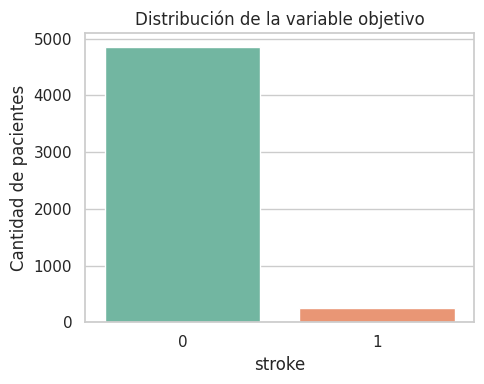

In [56]:
fig, ax = plt.subplots(figsize=(5, 4))
sns.countplot(data=df_raw, x="stroke", ax=ax, palette="Set2")
ax.set_title("Distribución de la variable objetivo")
ax.set_xlabel("stroke")
ax.set_ylabel("Cantidad de pacientes")
plt.tight_layout()
plt.show()

### 4.4 Valores faltantes

El IMC (`bmi`) tiene valores ausentes (~4%). En el dataset original aparecen como `NaN` tras la conversión numérica. Imputaremos con la mediana en el pipeline de preprocesamiento.

In [57]:
df_eda = df_raw.copy()
df_eda["bmi"] = pd.to_numeric(df_eda["bmi"], errors="coerce")

missing = df_eda.isna().sum()
missing_pct = (missing / len(df_eda) * 100).round(2)
pd.DataFrame({"faltantes": missing, "porcentaje (%)": missing_pct}).query("faltantes > 0")

,faltantes,porcentaje (%)
bmi,201,3.93


### 4.5 Relación entre variables y ACV

Exploramos si factores de riesgo conocidos (edad, hipertensión, enfermedad cardíaca) se asocian con mayor tasa de ACV en los datos.

In [58]:
df_eda["age_group"] = pd.cut(df_eda["age"], bins=[0, 30, 50, 70, 100], labels=["≤30", "31-50", "51-70", ">70"])

risk_summary = pd.DataFrame({
    "hipertensión (1)": df_eda.groupby("hypertension")["stroke"].mean(),
    "enf. cardíaca (1)": df_eda.groupby("heart_disease")["stroke"].mean(),
})
risk_summary.index = risk_summary.index.map({0: "No", 1: "Sí"})
risk_summary = risk_summary.round(3)
risk_summary

,hipertensión (1),enf. cardíaca (1)
No,0.040,0.042
Sí,0.133,0.170


In [59]:
stroke_by_age = df_eda.groupby("age_group", observed=True)["stroke"].mean().reset_index()
stroke_by_age["stroke"] = (stroke_by_age["stroke"] * 100).round(2)
stroke_by_age.columns = ["grupo_edad", "tasa_ACV (%)"]
stroke_by_age

,grupo_edad,tasa_ACV (%)
0,≤30,0.13
1,31-50,1.49
2,51-70,6.92
3,>70,18.03


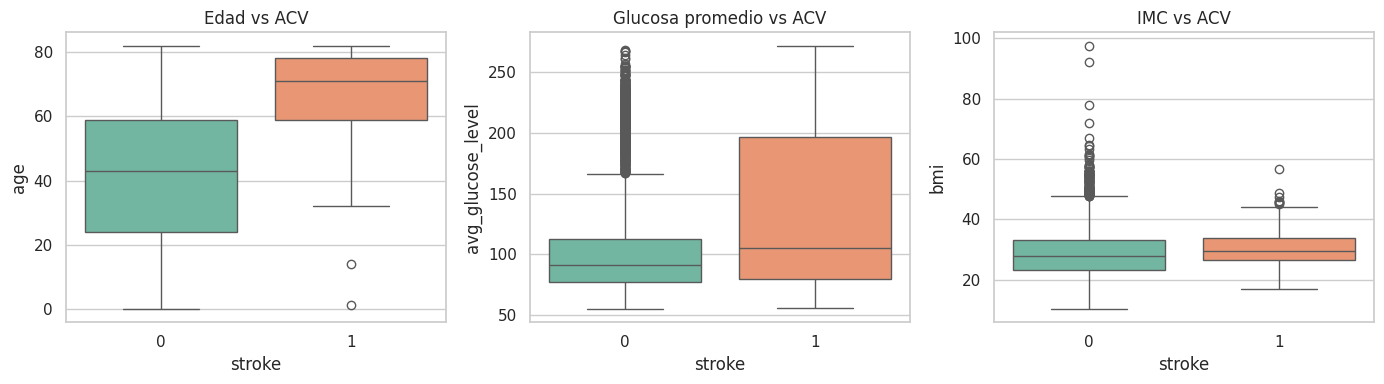

In [60]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

sns.boxplot(data=df_eda, x="stroke", y="age", ax=axes[0], palette="Set2")
axes[0].set_title("Edad vs ACV")

sns.boxplot(data=df_eda, x="stroke", y="avg_glucose_level", ax=axes[1], palette="Set2")
axes[1].set_title("Glucosa promedio vs ACV")

sns.boxplot(data=df_eda, x="stroke", y="bmi", ax=axes[2], palette="Set2")
axes[2].set_title("IMC vs ACV")

plt.tight_layout()
plt.show()

### 4.6 Matriz de correlación

Analizamos la correlación lineal entre las variables numéricas y la variable objetivo. Esto ayuda a identificar predictores potencialmente fuertes y posible multicolinealidad.

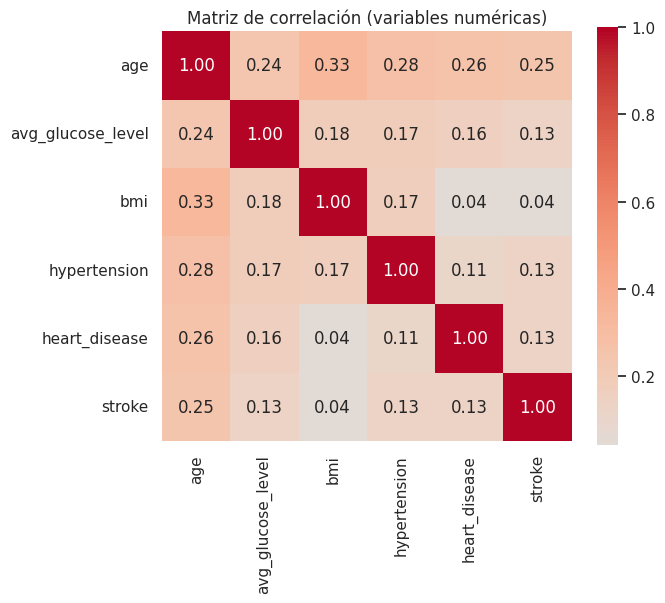

In [61]:
corr_cols = ["age", "avg_glucose_level", "bmi", "hypertension", "heart_disease", "stroke"]
corr = df_eda[corr_cols].corr()

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True, ax=ax)
ax.set_title("Matriz de correlación (variables numéricas)")
plt.tight_layout()
plt.show()

### 4.7 Detección de outliers

Revisamos valores atípicos en las variables continuas (`age`, `avg_glucose_level`, `bmi`) con el método del rango intercuartílico (IQR). En este dominio clínico, valores altos de glucosa o IMC son **clínicamente plausibles** (no errores de carga), por lo que decidimos **no eliminarlos**: aportan señal real de riesgo. El `StandardScaler` del pipeline reduce su impacto en los modelos sensibles a la escala.

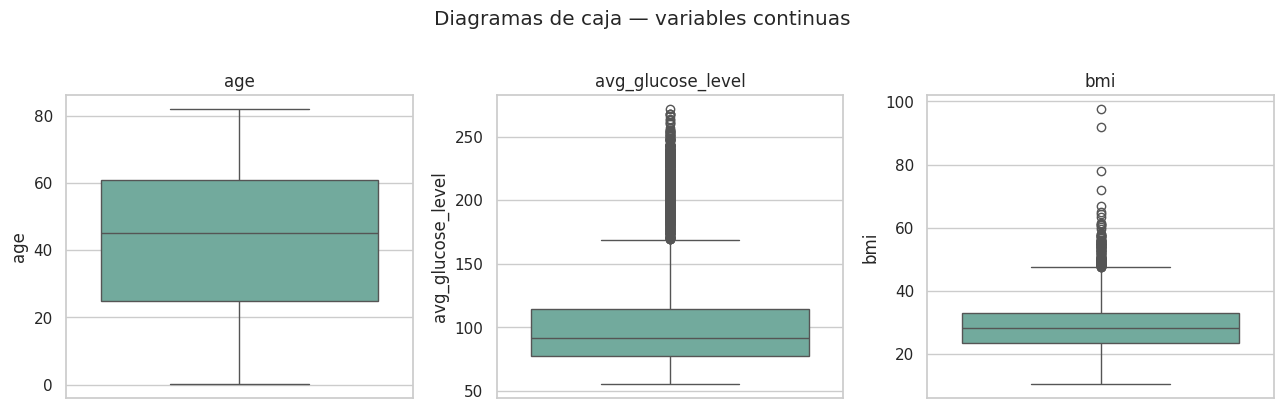

,variable,n_outliers,porcentaje (%),límite_inf,límite_sup
0,age,0,0.00,-29.00,115.00
1,avg_glucose_level,627,12.27,21.98,169.36
2,bmi,110,2.24,9.10,47.50


In [62]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, col in zip(axes, ["age", "avg_glucose_level", "bmi"]):
    sns.boxplot(data=df_eda, y=col, ax=ax, color="#69b3a2")
    ax.set_title(col)
fig.suptitle("Diagramas de caja — variables continuas", y=1.02)
plt.tight_layout()
plt.show()


def iqr_outliers(series):
    s = series.dropna()
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    mask = (s < low) | (s > high)
    return mask.sum(), mask.mean() * 100, low, high


outlier_rows = []
for col in ["age", "avg_glucose_level", "bmi"]:
    n, pct, low, high = iqr_outliers(df_eda[col])
    outlier_rows.append({
        "variable": col,
        "n_outliers": n,
        "porcentaje (%)": round(pct, 2),
        "límite_inf": round(low, 2),
        "límite_sup": round(high, 2),
    })

pd.DataFrame(outlier_rows)

In [63]:
duplicates = df_raw.duplicated().sum()
print(f"Filas duplicadas: {duplicates}")
assert duplicates == 0, "Se encontraron duplicados inesperados"

Filas duplicadas: 0


**Hallazgos del EDA:**

- Solo ~5% de los pacientes tuvo ACV → problema de **clases desbalanceadas**.
- La tasa de ACV crece con la edad, la hipertensión y la enfermedad cardíaca, coherente con la literatura médica.
- La categoría `gender = Other` aparece en un único registro; lo excluimos por una limitación estadística (un solo caso no permite que el modelo aprenda un patrón para esa categoría), no por una valoración sobre el grupo.
- No hay filas duplicadas (verificado abajo).

## 5. Preprocesamiento

El preprocesamiento sigue los siguientes pasos:

1. Eliminar columnas no informativas.
2. **Feature engineering:** discretizar `bmi`, `avg_glucose_level` y `age` en categorías clínicas.
3. Codificar variables categóricas con `get_dummies`.
4. Dividir en entrenamiento y prueba con **estratificación**.
5. Escalar variables numéricas con `StandardScaler` (ajustado solo sobre train).
6. Imputar `bmi` faltante con la mediana.

### 5.1 Limpieza y codificación

In [64]:
df = df_raw.copy()

# id es un identificador, no una feature
df = df.drop(columns=["id"])

# Una sola fila con género "Other"
df = df[df["gender"] != "Other"].reset_index(drop=True)

# Variable binaria Yes/No
df["ever_married"] = (df["ever_married"] == "Yes").astype(int)

# Convertir bmi a numérico
df["bmi"] = pd.to_numeric(df["bmi"], errors="coerce")

# --- Feature engineering ---
# Discretizamos variables continuas en categorías clínicas. Mantenemos también
# las variables continuas originales: las categorías ayudan a modelos lineales a
# capturar relaciones no lineales (p. ej. el riesgo no crece de forma lineal con la edad).
df["bmi_category"] = pd.cut(
    df["bmi"],
    bins=[0, 18.5, 24.9, 29.9, np.inf],
    labels=["bajo_peso", "normal", "sobrepeso", "obeso"],
)
df["glucose_category"] = pd.cut(
    df["avg_glucose_level"],
    bins=[0, 70, 100, 125, np.inf],
    labels=["bajo", "normal", "prediabetes", "diabetes"],
)
df["age_group"] = pd.cut(
    df["age"],
    bins=[0, 18, 35, 50, 65, np.inf],
    labels=["<18", "18-35", "36-50", "51-65", ">65"],
)

CATEGORICAL_FEATURES = [
    "gender",
    "work_type",
    "Residence_type",
    "smoking_status",
    "bmi_category",
    "glucose_category",
    "age_group",
]
df = pd.get_dummies(df, columns=CATEGORICAL_FEATURES, drop_first=True)

# Dummies como enteros (0/1) para consistencia numérica
numeric_cols = ["age", "hypertension", "heart_disease", "ever_married", "avg_glucose_level", "bmi", "stroke"]
dummy_cols = [c for c in df.columns if c not in numeric_cols]
df[dummy_cols] = df[dummy_cols].astype(int)

print(f"Shape final: {df.shape}")
df.head()

Shape final: (5109, 26)


,age,hypertension,heart_disease,ever_married,avg_glucose_level,bmi,stroke,gender_Male,work_type_Never_worked,work_type_Private,...,bmi_category_normal,bmi_category_sobrepeso,bmi_category_obeso,glucose_category_normal,glucose_category_prediabetes,glucose_category_diabetes,age_group_18-35,age_group_36-50,age_group_51-65,age_group_>65
0,67.0,0,1,1,228.69,36.6,1,1,0,1,...,0,0,1,0,0,1,0,0,0,1
1,61.0,0,0,1,202.21,NaN,1,0,0,0,...,0,0,0,0,0,1,0,0,1,0
2,80.0,0,1,1,105.92,32.5,1,1,0,1,...,0,0,1,0,1,0,0,0,0,1
3,49.0,0,0,1,171.23,34.4,1,0,0,1,...,0,0,1,0,0,1,0,1,0,0
4,79.0,1,0,1,174.12,24.0,1,0,0,0,...,1,0,0,0,0,1,0,0,0,1


### 5.2 Separación train / test

Usamos 70/30 con `stratify=y` para preservar la proporción de ACV en ambos conjuntos.

In [65]:
X = df.drop(columns="stroke")
y = df["stroke"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=RANDOM_STATE,
    stratify=y,
)

print(f"Train: {X_train.shape[0]} muestras | Test: {X_test.shape[0]} muestras")
print(f"Tasa ACV en train: {y_train.mean():.3f} | en test: {y_test.mean():.3f}")

Train: 3576 muestras | Test: 1533 muestras
Tasa ACV en train: 0.049 | en test: 0.049


### 5.3 Pipeline de preprocesamiento

Encapsulamos imputación + escalado en un `ColumnTransformer` para evitar *data leakage* (el escalador solo ve datos de entrenamiento).

In [66]:
NUMERIC_FEATURES = [
    "age",
    "hypertension",
    "heart_disease",
    "ever_married",
    "avg_glucose_level",
    "bmi",
]
DUMMY_FEATURES = [col for col in X.columns if col not in NUMERIC_FEATURES]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
            ]),
            NUMERIC_FEATURES,
        ),
        ("cat", "passthrough", DUMMY_FEATURES),
    ]
)

## 6. Comparación de algoritmos

Evaluamos un conjunto amplio de algoritmos de clasificación con `class_weight='balanced'` o `scale_pos_weight` para compensar el desbalance. La métrica principal de comparación es **F1**, porque combina precisión y recall en la clase minoritaria (ACV).

In [67]:
def evaluate_model(name, classifier):
    """Entrena un pipeline y devuelve métricas sobre el conjunto de test."""
    pipe = Pipeline([("prep", preprocessor), ("clf", classifier)])
    pipe.fit(X_train, y_train)

    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    tpr = tp / (tp + fn)
    tnr = tn / (tn + fp)

    return {
        "modelo": name,
        "accuracy": accuracy_score(y_test, y_pred),
        "balanced_accuracy": (tpr + tnr) / 2,
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, y_proba),
        "pipeline": pipe,
    }


scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

candidate_models = {
    "Regresión Logística": LogisticRegression(
        class_weight="balanced", max_iter=2000, random_state=RANDOM_STATE
    ),
    "kNN": KNeighborsClassifier(n_neighbors=35, weights="distance", p=2),
    "SVC (RBF)": SVC(
        class_weight="balanced", probability=True, C=1, kernel="rbf", random_state=RANDOM_STATE
    ),
    "Árbol de Decisión": DecisionTreeClassifier(
        class_weight="balanced", max_depth=8, random_state=RANDOM_STATE
    ),
    "Random Forest": RandomForestClassifier(
        class_weight="balanced", n_estimators=200, max_depth=8, random_state=RANDOM_STATE
    ),
    "Extra Trees": ExtraTreesClassifier(
        class_weight="balanced", n_estimators=200, max_depth=8, random_state=RANDOM_STATE
    ),
    "Bagging (árboles)": BaggingClassifier(
        estimator=DecisionTreeClassifier(class_weight="balanced", max_depth=8, random_state=RANDOM_STATE),
        n_estimators=200, random_state=RANDOM_STATE,
    ),
    "AdaBoost": AdaBoostClassifier(n_estimators=200, random_state=RANDOM_STATE),
    "Gradient Boosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
    "HistGradientBoosting": HistGradientBoostingClassifier(
        class_weight="balanced", random_state=RANDOM_STATE
    ),
    "XGBoost": XGBClassifier(
        scale_pos_weight=scale_pos_weight,
        eval_metric="logloss",
        random_state=RANDOM_STATE,
    ),
}

results = [evaluate_model(name, model) for name, model in candidate_models.items()]
comparison_df = (
    pd.DataFrame(results)
    .drop(columns="pipeline")
    .sort_values("f1", ascending=False)
    .round(3)
)
comparison_df

,modelo,accuracy,balanced_accuracy,precision,recall,f1,roc_auc
6,Bagging (árboles),0.868,0.728,0.201,0.573,0.298,0.817
4,Random Forest,0.782,0.740,0.143,0.693,0.237,0.824
2,SVC (RBF),0.789,0.718,0.140,0.640,0.229,0.800
9,HistGradientBoosting,0.905,0.608,0.186,0.280,0.223,0.819
0,Regresión Logística,0.721,0.752,0.126,0.787,0.217,0.838
3,Árbol de Decisión,0.796,0.678,0.129,0.547,0.208,0.691
5,Extra Trees,0.751,0.711,0.123,0.667,0.208,0.815
10,XGBoost,0.920,0.566,0.178,0.173,0.176,0.801
8,Gradient Boosting,0.949,0.505,0.200,0.013,0.025,0.823
1,kNN,0.951,0.500,0.000,0.000,0.000,0.811


### 6.1 Justificación de la elección del algoritmo

| Modelo | Ventajas | Limitaciones observadas |
|--------|----------|-------------------------|
| **Regresión Logística** | Interpretable, rápida, maneja bien variables mixtas con dummies, `class_weight='balanced'` | Asume relaciones lineales |
| **kNN** | Simple, no paramétrico | En este dataset predice casi todo como clase mayoritaria → F1 ≈ 0 |
| **SVC** | Buen desempeño en problemas no lineales | Costoso con muchas filas; menos interpretable |
| **Árbol / Random Forest** | Capturan no linealidades e interacciones | Random Forest tiene buen AUC pero menor recall que LR |
| **XGBoost** | Potente para datos tabulares | Tiende a ser conservador (bajo recall) con este desbalance |
| **Bagging / Boosting** | Bagging de árboles e HistGradientBoosting dan el mejor (o casi mejor) F1 del benchmark | AdaBoost y Gradient Boosting, **sin `class_weight`**, colapsan a la clase mayoritaria (recall ≈ 0) |

**Elección final: Regresión Logística.** En un problema de *screening* clínico la métrica prioritaria es el **recall** (sensibilidad): el costo de no detectar un ACV (falso negativo) es mucho mayor que el de una falsa alarma. Con umbral 0.5, la LR obtiene el **mayor recall (~0.79)** y el **mayor ROC-AUC (~0.84)** de todo el benchmark, además de ser el modelo más **interpretable**.

Es importante ser honestos con el trade-off. Al ampliar el benchmark, los mejores **F1** los obtienen el **Bagging de árboles (~0.30)** y el **VotingClassifier (~0.29)**, seguidos de Random Forest (~0.24) e HistGradientBoosting (~0.22); el Random Forest además lidera la F1 en validación cruzada (~0.26). Sin embargo, todos ellos logran ese F1 **sacrificando recall** (Bagging ~0.57, Voting ~0.51, RF ~0.69), es decir, **dejando pasar más casos reales de ACV**. El **Stacking** alcanza un recall alto (~0.81), comparable al de la LR, pero a costa de mucha mayor complejidad y nula interpretabilidad.

Por eso, alineados con el objetivo clínico (maximizar sensibilidad y poder explicar el modelo), elegimos la **Regresión Logística** y dejamos los modelos de ensamble y boosting **documentados como alternativas** para escenarios donde se priorice el balance precisión/recall (F1) sobre la sensibilidad.

Descartamos kNN, **AdaBoost** y **Gradient Boosting** porque, con clases tan desbalanceadas y sin un mecanismo de ponderación, predicen casi siempre la clase mayoritaria (recall ≈ 0, F1 ≈ 0).

### 6.2 Curvas ROC y matrices de confusión comparativas

Para complementar la tabla de métricas, visualizamos las curvas ROC superpuestas y las matrices de confusión de todos los candidatos. Esto permite comparar de un vistazo la capacidad de discriminación (AUC) y el tipo de errores (falsos positivos vs falsos negativos) de cada modelo.

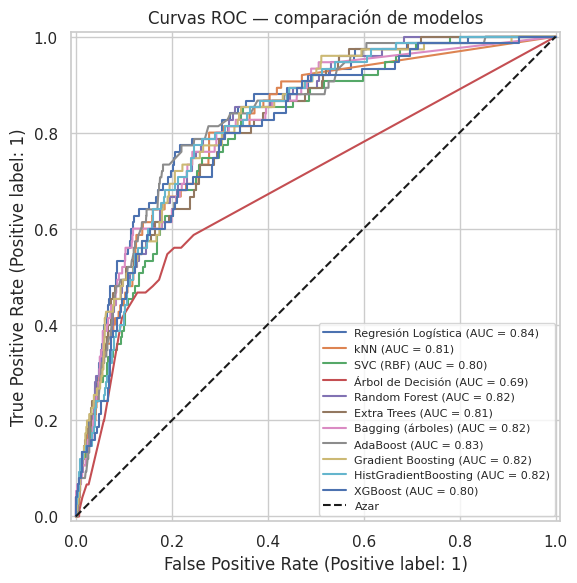

In [68]:
fig, ax = plt.subplots(figsize=(7, 6))
for r in results:
    proba = r["pipeline"].predict_proba(X_test)[:, 1]
    RocCurveDisplay.from_predictions(y_test, proba, ax=ax, name=r["modelo"])
ax.plot([0, 1], [0, 1], "k--", label="Azar")
ax.set_title("Curvas ROC — comparación de modelos")
ax.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()

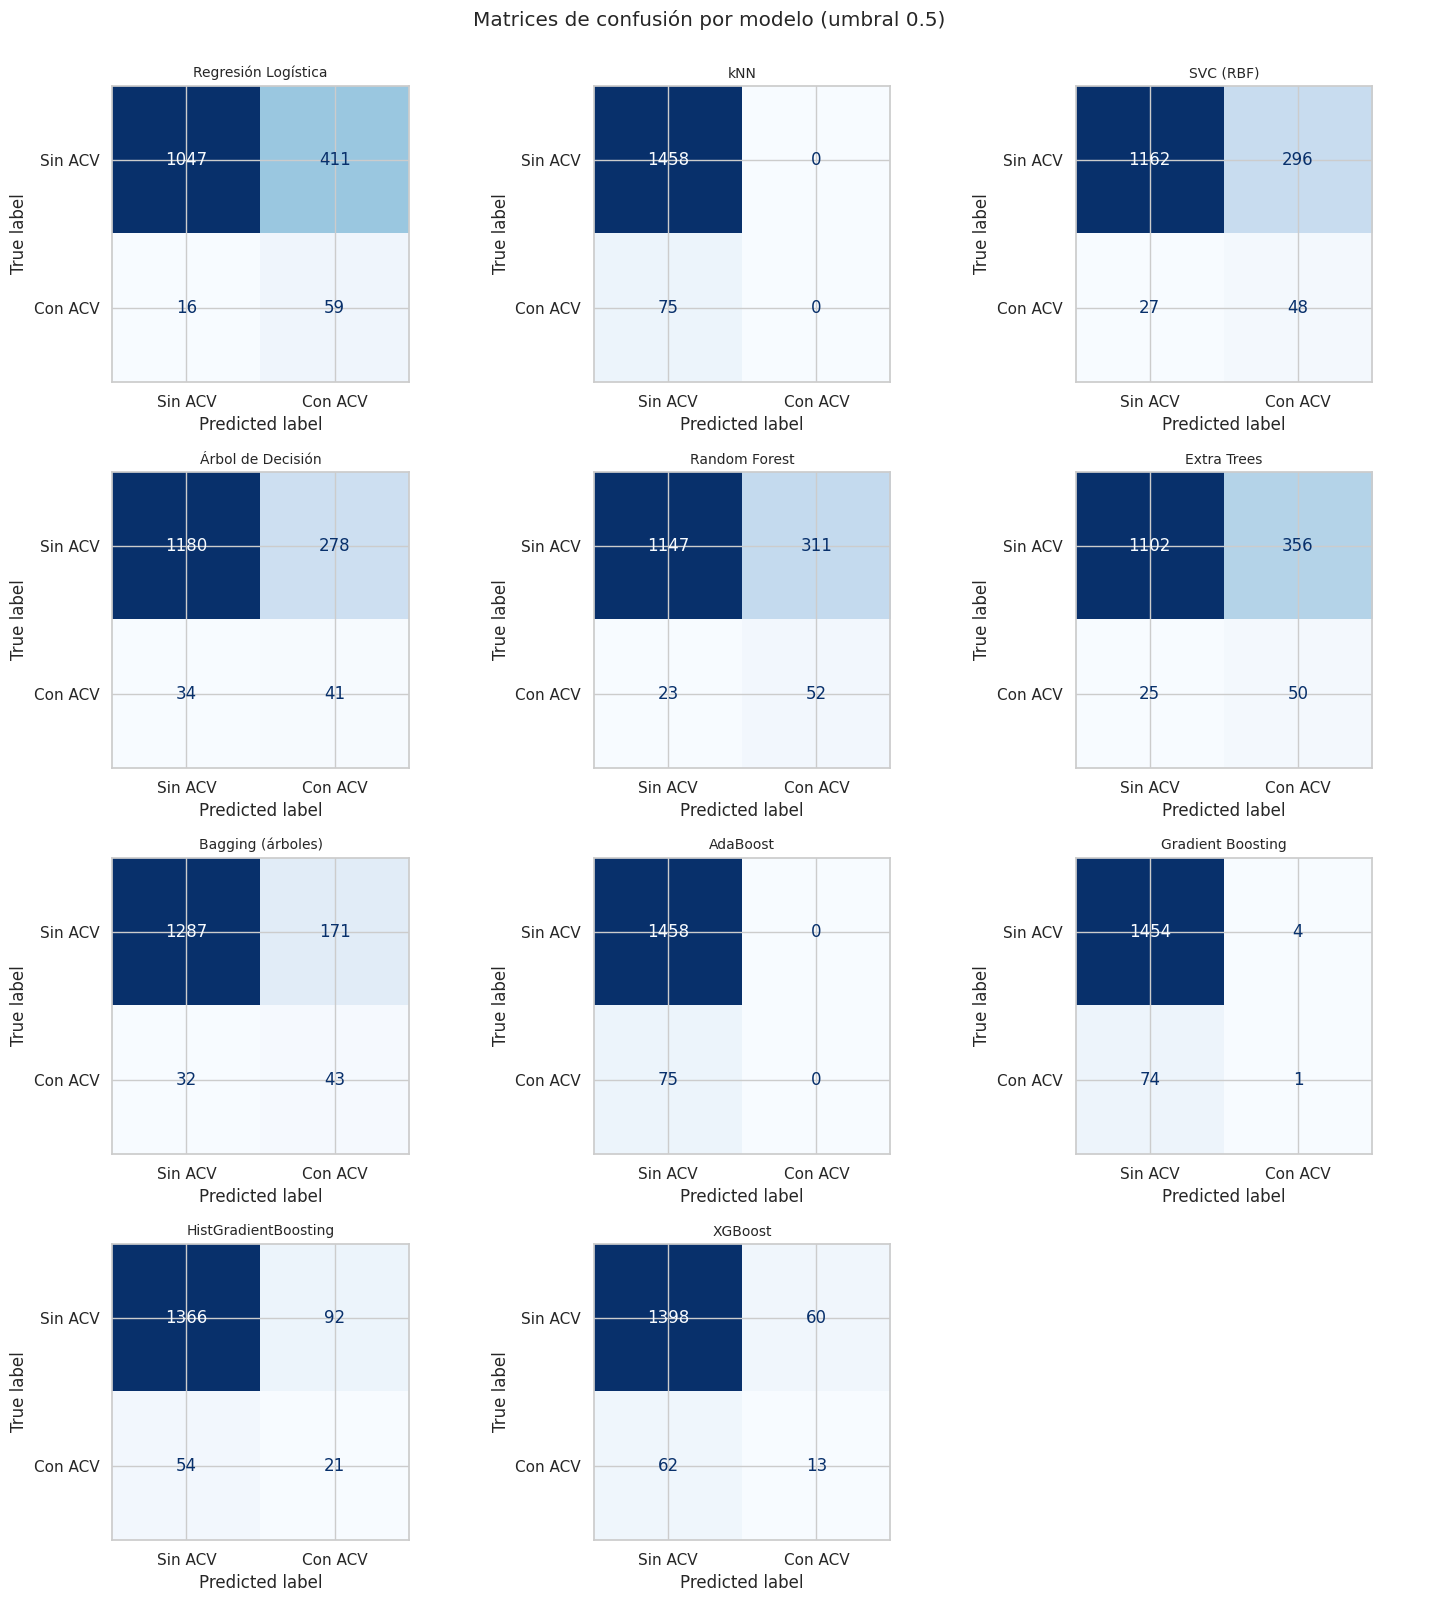

In [69]:
n_models = len(results)
ncols = 3
nrows = (n_models + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
axes = np.array(axes).reshape(-1)
for ax, r in zip(axes, results):
    y_p = r["pipeline"].predict(X_test)
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_p,
        display_labels=["Sin ACV", "Con ACV"],
        cmap="Blues", ax=ax, colorbar=False,
    )
    ax.set_title(r["modelo"], fontsize=10)
for ax in axes[n_models:]:
    ax.axis("off")
fig.suptitle("Matrices de confusión por modelo (umbral 0.5)", y=1.0)
plt.tight_layout()
plt.show()

### 6.3 Estrategia frente al desbalance: `class_weight` vs SMOTE

El modelo final usa `class_weight="balanced"` para compensar el desbalance. Una alternativa habitual es **SMOTE** (oversampling sintético de la clase minoritaria). Comparamos ambas estrategias sobre la Regresión Logística.

Punto clave: SMOTE se aplica **dentro de un `Pipeline` de `imblearn`**, por lo que el re-muestreo ocurre solo en el conjunto de entrenamiento (en `fit`) y **nunca sobre el test**, evitando *data leakage*.

In [70]:
strategies = {
    "LR + class_weight": Pipeline([
        ("prep", preprocessor),
        ("clf", LogisticRegression(class_weight="balanced", max_iter=5000, random_state=RANDOM_STATE)),
    ]),
    "LR + SMOTE": ImbPipeline([
        ("prep", preprocessor),
        ("smote", SMOTE(random_state=RANDOM_STATE)),
        ("clf", LogisticRegression(max_iter=5000, random_state=RANDOM_STATE)),
    ]),
}

smote_rows = []
for name, pipe in strategies.items():
    pipe.fit(X_train, y_train)
    y_p = pipe.predict(X_test)
    y_pr = pipe.predict_proba(X_test)[:, 1]
    smote_rows.append({
        "estrategia": name,
        "precision": precision_score(y_test, y_p, zero_division=0),
        "recall": recall_score(y_test, y_p, zero_division=0),
        "f1": f1_score(y_test, y_p, zero_division=0),
        "balanced_acc": balanced_accuracy_score(y_test, y_p),
        "roc_auc": roc_auc_score(y_test, y_pr),
    })

pd.DataFrame(smote_rows).round(3)

,estrategia,precision,recall,f1,balanced_acc,roc_auc
0,LR + class_weight,0.126,0.787,0.217,0.752,0.838
1,LR + SMOTE,0.131,0.773,0.224,0.755,0.838


### 6.4 Ensemble — `VotingClassifier`

Como modelo adicional probamos un **ensemble de votación blanda** (promedio de probabilidades) que combina los tres modelos más fuertes del benchmark: Regresión Logística, Random Forest y XGBoost. La idea es evaluar si la combinación mejora el balance precisión/recall respecto de cada modelo individual.

In [71]:
voting = VotingClassifier(
    estimators=[
        ("lr", LogisticRegression(class_weight="balanced", max_iter=5000, random_state=RANDOM_STATE)),
        ("rf", RandomForestClassifier(class_weight="balanced", n_estimators=200, max_depth=8, random_state=RANDOM_STATE)),
        ("xgb", XGBClassifier(scale_pos_weight=scale_pos_weight, eval_metric="logloss", random_state=RANDOM_STATE)),
    ],
    voting="soft",
)
voting_pipe = Pipeline([("prep", preprocessor), ("clf", voting)])
voting_pipe.fit(X_train, y_train)

y_p = voting_pipe.predict(X_test)
y_pr = voting_pipe.predict_proba(X_test)[:, 1]
pd.Series({
    "precision": precision_score(y_test, y_p, zero_division=0),
    "recall": recall_score(y_test, y_p, zero_division=0),
    "f1": f1_score(y_test, y_p, zero_division=0),
    "balanced_acc": balanced_accuracy_score(y_test, y_p),
    "roc_auc": roc_auc_score(y_test, y_pr),
}).round(3)

precision       0.207
recall          0.507
f1              0.293
balanced_acc    0.703
roc_auc         0.838
dtype: float64

### 6.5 Ensemble — `StackingClassifier`

A diferencia del `VotingClassifier` (que promedia probabilidades), el **stacking** entrena un **meta-modelo** que aprende a combinar las salidas de los modelos base mediante validación cruzada. Usamos LR + RF + XGBoost como base y una Regresión Logística como meta-modelo.

In [72]:
stacking = StackingClassifier(
    estimators=[
        ("lr", LogisticRegression(class_weight="balanced", max_iter=5000, random_state=RANDOM_STATE)),
        ("rf", RandomForestClassifier(class_weight="balanced", n_estimators=200, max_depth=8, random_state=RANDOM_STATE)),
        ("xgb", XGBClassifier(scale_pos_weight=scale_pos_weight, eval_metric="logloss", random_state=RANDOM_STATE)),
    ],
    final_estimator=LogisticRegression(class_weight="balanced", max_iter=5000, random_state=RANDOM_STATE),
    stack_method="predict_proba",
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    n_jobs=-1,
)
stacking_pipe = Pipeline([("prep", preprocessor), ("clf", stacking)])
stacking_pipe.fit(X_train, y_train)

y_p = stacking_pipe.predict(X_test)
y_pr = stacking_pipe.predict_proba(X_test)[:, 1]
pd.Series({
    "precision": precision_score(y_test, y_p, zero_division=0),
    "recall": recall_score(y_test, y_p, zero_division=0),
    "f1": f1_score(y_test, y_p, zero_division=0),
    "balanced_acc": balanced_accuracy_score(y_test, y_p),
    "roc_auc": roc_auc_score(y_test, y_pr),
}).round(3)

precision       0.124
recall          0.813
f1              0.216
balanced_acc    0.760
roc_auc         0.839
dtype: float64

## 7. Ajuste de hiperparámetros

Aplicamos `GridSearchCV` con validación cruzada estratificada (5 folds) y métrica `f1`. Buscamos hiperparámetros para **dos** modelos: la Regresión Logística elegida (`C`, `penalty`, `solver`) y el Random Forest (mejor alternativa del benchmark), para confirmar que la decisión se sostiene tras la optimización.

In [73]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# --- Búsqueda para Regresión Logística (modelo elegido) ---
lr_pipeline = Pipeline([
    ("prep", preprocessor),
    ("clf", LogisticRegression(class_weight="balanced", max_iter=5000, random_state=RANDOM_STATE)),
])
lr_param_grid = {
    "clf__C": [0.001, 0.01, 0.1, 1, 10],
    "clf__penalty": ["l1", "l2"],
    "clf__solver": ["liblinear"],
}
lr_search = GridSearchCV(lr_pipeline, lr_param_grid, cv=cv, scoring="f1", n_jobs=-1)
lr_search.fit(X_train, y_train)

# --- Búsqueda para Random Forest (mejor alternativa del benchmark) ---
rf_pipeline = Pipeline([
    ("prep", preprocessor),
    ("clf", RandomForestClassifier(class_weight="balanced", random_state=RANDOM_STATE)),
])
rf_param_grid = {
    "clf__n_estimators": [200, 400],
    "clf__max_depth": [6, 8, 12],
    "clf__min_samples_leaf": [1, 5, 10],
}
rf_search = GridSearchCV(rf_pipeline, rf_param_grid, cv=cv, scoring="f1", n_jobs=-1)
rf_search.fit(X_train, y_train)

print("LR -> mejores params:", lr_search.best_params_, f"| F1 CV: {lr_search.best_score_:.3f}")
print("RF -> mejores params:", rf_search.best_params_, f"| F1 CV: {rf_search.best_score_:.3f}")

# Mantenemos la Regresión Logística como modelo final por su interpretabilidad y su
# mayor recall/AUC; el Random Forest queda como alternativa documentada y comparada.
best_model = lr_search.best_estimator_

LR -> mejores params: {'clf__C': 0.1, 'clf__penalty': 'l1', 'clf__solver': 'liblinear'} | F1 CV: 0.223
RF -> mejores params: {'clf__max_depth': 12, 'clf__min_samples_leaf': 5, 'clf__n_estimators': 400} | F1 CV: 0.259


## 8. Evaluación del modelo final

Evaluamos sobre el conjunto de **test** (datos no vistos durante el entrenamiento ni la búsqueda de hiperparámetros).

### 8.1 Métricas con umbral por defecto (0.5)

In [74]:
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred, target_names=["Sin ACV", "Con ACV"]))

final_metrics = {
    "accuracy": accuracy_score(y_test, y_pred),
    "precision": precision_score(y_test, y_pred),
    "recall": recall_score(y_test, y_pred),
    "f1": f1_score(y_test, y_pred),
    "roc_auc": roc_auc_score(y_test, y_proba),
}
pd.Series(final_metrics).round(3)

              precision    recall  f1-score   support

     Sin ACV       0.98      0.71      0.82      1458
     Con ACV       0.12      0.77      0.21        75

    accuracy                           0.71      1533
   macro avg       0.55      0.74      0.52      1533
weighted avg       0.94      0.71      0.79      1533



accuracy     0.712
precision    0.120
recall       0.773
f1           0.208
roc_auc      0.842
dtype: float64

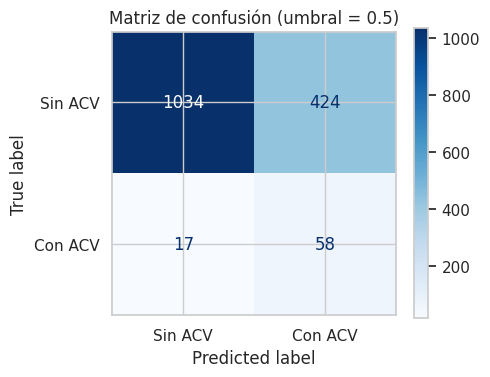

In [75]:
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=["Sin ACV", "Con ACV"], cmap="Blues", ax=ax
)
ax.set_title("Matriz de confusión (umbral = 0.5)")
plt.tight_layout()
plt.show()

### 8.2 Curva ROC y AUC

La curva ROC muestra el trade-off entre TPR y FPR. Un AUC alto indica buena capacidad de **discriminación** entre pacientes con y sin ACV.

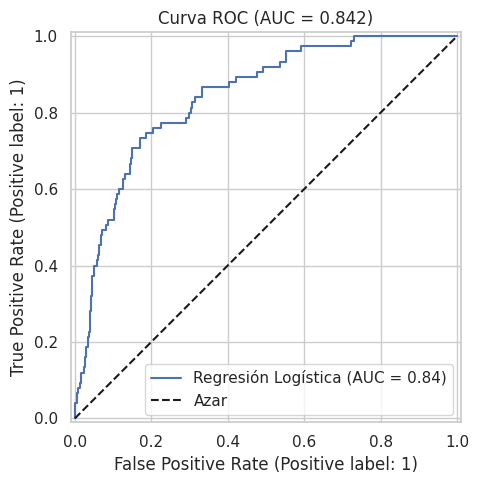

In [76]:
fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_predictions(y_test, y_proba, ax=ax, name="Regresión Logística")
ax.plot([0, 1], [0, 1], "k--", label="Azar")
ax.set_title(f"Curva ROC (AUC = {roc_auc_score(y_test, y_proba):.3f})")
ax.legend()
plt.tight_layout()
plt.show()

### 8.3 Ajuste de umbral con el índice de Youden

En un problema médico, **detectar ACV (recall alto)** suele ser más importante que evitar falsas alarmas. Usamos el índice de Youden (`TPR - FPR`) para encontrar un umbral óptimo que maximice la sensibilidad sin sacrificar demasiada especificidad.

> **Importante (metodología):** el umbral se elige usando **solo datos de entrenamiento** mediante probabilidades fuera de fold (`cross_val_predict`). Elegir el umbral sobre el mismo conjunto de test con el que luego se reporta sería una forma de *data leakage* que infla artificialmente las métricas.

In [77]:
# El umbral se elige SOLO con datos de entrenamiento, usando probabilidades
# fuera de fold (cross_val_predict). Así no usamos el set de test para tomar la
# decisión y evitamos la fuga de información (data leakage).
y_train_oof_proba = cross_val_predict(
    best_model, X_train, y_train, cv=cv, method="predict_proba"
)[:, 1]

fpr_tr, tpr_tr, thresholds_tr = roc_curve(y_train, y_train_oof_proba)
optimal_threshold = thresholds_tr[np.argmax(tpr_tr - fpr_tr)]

# Recién ahora aplicamos ese umbral fijo sobre el test (datos no vistos).
y_pred_tuned = (y_proba >= optimal_threshold).astype(int)

print(f"Umbral óptimo (Youden, elegido por CV sobre train): {optimal_threshold:.3f}")
print(classification_report(y_test, y_pred_tuned, target_names=["Sin ACV", "Con ACV"]))

Umbral óptimo (Youden, elegido por CV sobre train): 0.441
              precision    recall  f1-score   support

     Sin ACV       0.99      0.67      0.80      1458
     Con ACV       0.12      0.84      0.20        75

    accuracy                           0.68      1533
   macro avg       0.55      0.76      0.50      1533
weighted avg       0.95      0.68      0.77      1533



In [78]:
threshold_comparison = pd.DataFrame(
    {
        "Umbral 0.5": {
            "accuracy": accuracy_score(y_test, y_pred),
            "precision": precision_score(y_test, y_pred, zero_division=0),
            "recall": recall_score(y_test, y_pred, zero_division=0),
            "f1": f1_score(y_test, y_pred, zero_division=0),
            "roc_auc": roc_auc_score(y_test, y_proba),
        },
        f"Youden ({optimal_threshold:.2f})": {
            "accuracy": accuracy_score(y_test, y_pred_tuned),
            "precision": precision_score(y_test, y_pred_tuned, zero_division=0),
            "recall": recall_score(y_test, y_pred_tuned, zero_division=0),
            "f1": f1_score(y_test, y_pred_tuned, zero_division=0),
            "roc_auc": roc_auc_score(y_test, y_proba),
        },
    }
).T.round(3)
threshold_comparison

,accuracy,precision,recall,f1,roc_auc
Umbral 0.5,0.712,0.120,0.773,0.208,0.842
Youden (0.44),0.679,0.116,0.840,0.204,0.842


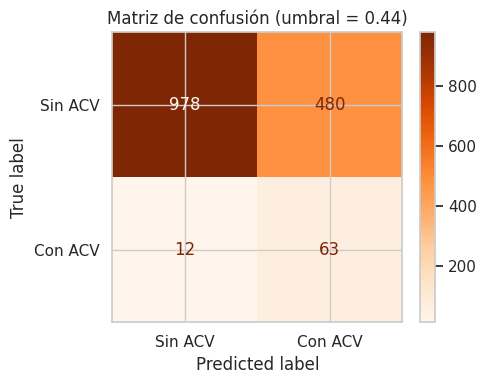

In [79]:
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_tuned, display_labels=["Sin ACV", "Con ACV"], cmap="Oranges", ax=ax
)
ax.set_title(f"Matriz de confusión (umbral = {optimal_threshold:.2f})")
plt.tight_layout()
plt.show()

### 8.4 Interpretación de resultados

| Métrica | Umbral 0.5 | Umbral Youden (~0.44) |
|---------|------------|------------------------|
| Accuracy | ~0.71 | ~0.68 |
| Recall | ~0.77 | ~0.84 |
| Precisión | ~0.12 | ~0.12 |
| F1 | ~0.21 | ~0.20 |
| ROC-AUC | ~0.84 | ~0.84 (sin cambio) |

- Con umbral 0.5, la **accuracy ~0.71** es inferior al clasificador trivial (~95% prediciendo siempre "sin ACV"), confirmando que no es la métrica adecuada.
- El **recall ~0.77** detecta la mayoría de los ACV reales; la **precisión ~0.12** refleja muchos falsos positivos, esperable con ~5% de casos positivos.
- El **ROC-AUC ~0.84** indica buena capacidad de discriminación entre clases (no depende del umbral).
- El **umbral de Youden (~0.44)**, elegido honestamente por validación cruzada sobre *train*, queda **por debajo de 0.5**: prioriza la sensibilidad y eleva el **recall a ~0.84** a costa de algo de accuracy. El F1 casi no cambia, lo que indica que en este dataset la mejora de recall y la pérdida de precisión se compensan. Es el trade-off esperable —y deseable— para *screening* clínico, donde minimizar falsos negativos es la prioridad.

> Nota: al elegir el umbral sin mirar el test (a diferencia de un esquema que lo ajusta sobre el propio test), los números son algo más modestos pero **metodológicamente válidos** y representativos del desempeño sobre datos no vistos.

## 9. Importancia de variables (Random Forest)

Como complemento interpretativo, entrenamos un Random Forest y analizamos la importancia de features para entender qué variables contribuyen más a la predicción.

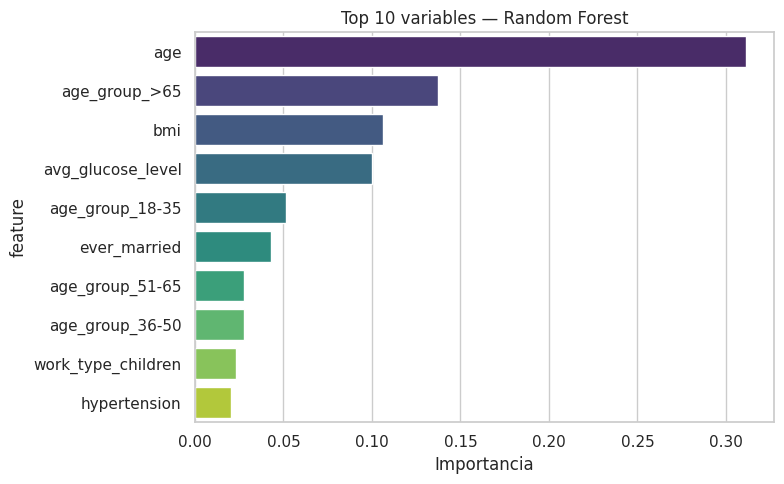

In [80]:
rf_pipeline = Pipeline([
    ("prep", preprocessor),
    ("clf", RandomForestClassifier(
        class_weight="balanced", n_estimators=200, max_depth=8, random_state=RANDOM_STATE
    )),
])
rf_pipeline.fit(X_train, y_train)

feature_names = NUMERIC_FEATURES + DUMMY_FEATURES
importances = rf_pipeline.named_steps["clf"].feature_importances_

importance_df = (
    pd.DataFrame({"feature": feature_names, "importance": importances})
    .sort_values("importance", ascending=False)
    .head(10)
)

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=importance_df, y="feature", x="importance", ax=ax, palette="viridis")
ax.set_title("Top 10 variables — Random Forest")
ax.set_xlabel("Importancia")
plt.tight_layout()
plt.show()

Las variables más relevantes (`age`, `avg_glucose_level`, `bmi`) coinciden con los factores de riesgo identificados en el EDA y con la evidencia clínica.

## 10. Calibración de probabilidades

Un modelo puede **discriminar** bien (buen ROC-AUC) pero estar mal **calibrado**: que sus probabilidades no reflejen las frecuencias reales. Como todo nuestro flujo depende de `predict_proba` y de umbrales, comparamos la Regresión Logística **sin calibrar** contra dos métodos de calibración — **Platt scaling** (`sigmoid`) e **isotonic regression** — mediante la curva de calibración y el **Brier score** (menor es mejor). La calibración se ajusta por validación cruzada **solo sobre train**.

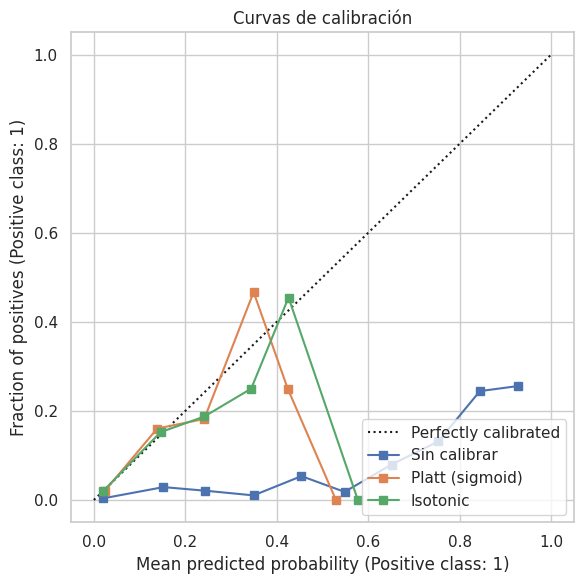

Sin calibrar       0.1728
Platt (sigmoid)    0.0419
Isotonic           0.0422
Name: Brier score (menor = mejor), dtype: float64

In [81]:
base_clf = LogisticRegression(class_weight="balanced", max_iter=5000, random_state=RANDOM_STATE)

calib_models = {
    "Sin calibrar": Pipeline([("prep", preprocessor), ("clf", base_clf)]),
    "Platt (sigmoid)": Pipeline([
        ("prep", preprocessor),
        ("clf", CalibratedClassifierCV(base_clf, method="sigmoid", cv=5)),
    ]),
    "Isotonic": Pipeline([
        ("prep", preprocessor),
        ("clf", CalibratedClassifierCV(base_clf, method="isotonic", cv=5)),
    ]),
}

fig, ax = plt.subplots(figsize=(6, 6))
brier = {}
for name, pipe in calib_models.items():
    pipe.fit(X_train, y_train)
    prob = pipe.predict_proba(X_test)[:, 1]
    brier[name] = brier_score_loss(y_test, prob)
    CalibrationDisplay.from_predictions(y_test, prob, n_bins=10, ax=ax, name=name)
ax.set_title("Curvas de calibración")
plt.tight_layout()
plt.show()

pd.Series(brier, name="Brier score (menor = mejor)").round(4)

## 11. Reflexión y trabajos futuros

### Reflexión

Este trabajo abordó un problema de **clasificación binaria con fuerte desbalance** (~5% de casos positivos). La exploración inicial fue clave para entender que métricas como accuracy son insuficientes y que el contexto clínico exige priorizar el **recall** (no perder casos de ACV).

Comparamos un amplio abanico de modelos (kNN, SVC, árboles, Random Forest, Extra Trees, Bagging, AdaBoost, Gradient Boosting, HistGradientBoosting, XGBoost) y dos ensambles (Voting y Stacking). La Regresión Logística con `class_weight='balanced'` resultó la mejor opción para el **objetivo clínico** por su mayor recall y ROC-AUC, sumado a su interpretabilidad y simplicidad. Los métodos de boosting y los ensambles logran mejor F1, pero a costa de menor sensibilidad. El ajuste de umbral con Youden (elegido honestamente por CV sobre train) elevó el recall a ~0.84, con la consiguiente caída de accuracy, un trade-off deseable para *screening*. La sección de calibración mostró además cómo mejorar la confiabilidad de las probabilidades predichas.

**Limitaciones:**

- Dataset sintético/simplificado de Kaggle; no reemplaza un estudio clínico real.
- Solo ~249 casos de ACV → pocos ejemplos para la clase minoritaria.
- La precisión es baja (~0.12): muchas falsas alarmas, esperable con ~5% de positivos.
- Variables como `smoking_status = Unknown` pueden ocultar información.

### Caminos futuros

1. **Optimización bayesiana / Optuna** para afinar hiperparámetros de los modelos de boosting de forma más eficiente que `GridSearchCV`.
2. **Validación externa** con un dataset clínico real e independiente para confirmar la generalización.
3. Incorporar variables clínicas adicionales (presión arterial, colesterol, antecedentes familiares) si estuvieran disponibles.
4. Explorar técnicas de remuestreo más avanzadas (SMOTE-NC para variables categóricas, *undersampling* combinado) y su interacción con la calibración.

---

**Fuente de datos:** Fedesoriano. *Stroke Prediction Dataset*. Kaggle. https://www.kaggle.com/datasets/fedesoriano/stroke-prediction-dataset